## Ablation study on feature groups 

In [14]:
import numpy as np
import pickle
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from cluster_utils import*

from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage 
from scipy.cluster.hierarchy import fcluster
from scipy.cluster.hierarchy import dendrogram



try:
    with open('weightedFrames.pkl', 'rb') as f:
        frameMatrix = pickle.load(f)
except:
    print("Error")


In [10]:
#dividing feature groups

gpdMatrix = frameMatrix[:, :50]
tableMatrix = frameMatrix[:, 50:55] 
interpersonMatrix = frameMatrix[:, 55:] 

In [15]:
##grouping per operation
OP_RANGES = [
    (0, 6),      # day3 op6: 7
    (7, 29),     # day3 op3: 23
    (30, 37),    # day3 op9: 8
    (38, 70),    # day3 op5: 33
    (71, 80),    # day3 op8: 10
    (81, 101),   # day3 op4: 21
    (102, 122),  # day3 op7: 21
    (123, 137),  # day3 op11: 15
    (138, 154),  # day3 op2: 17
    (155, 167),  # day3 op10: 13
    (168, 174),  # day3 op1: 7
    (175, 279),  # day2 op1: 105
    (280, 302),  # day2 op9: 23
    (303, 399),  # day2 op2: 97
    (400, 411),  # day2 op6: 12
    (412, 418),  # day2 op7: 7
    (419, 429),  # day2 op5: 11
    (430, 440),  # day2 op8: 11
    (441, 444),  # day2 op11: 4
    (445, 452),  # day2 op4: 8
    # (453, 454),  # day2 op3: 2
    # (455, 456),  # day2 op10: 2 <-- excluded due to length
    (457, 526),  # day4 op1: 70
    (527, 567),  # day4 op2: 41
    (568, 572),  # day4 op3: 5
    (573, 625),  # day1 op1: 53
]


#group per operation for each feature type
gpdVectors = []
tableVectors = []
interpersonVectors = []

for r in OP_RANGES:
    op = gpdMatrix[r[0]:r[1]+1,]
    gpdVectors.append(op)

for r in OP_RANGES:
    op = tableMatrix[r[0]:r[1]+1,]
    tableVectors.append(op)


for r in OP_RANGES:
    op = interpersonMatrix[r[0]:r[1]+1,]
    interpersonVectors.append(op)

opLabels = [f"op{i}" for i in range(1, 25)]



In [16]:
gpdDists = n_dtw(gpdVectors)
gpdEmbedding = TSNE(n_components=2, metric='precomputed', 
                 random_state=42, init='random', 
                 perplexity=5).fit_transform(gpdDists)

tableDists = n_dtw(tableVectors)
tableEmbedding = TSNE(n_components=2, metric='precomputed', 
                 random_state=42, init='random', 
                 perplexity=5).fit_transform(tableDists)

interpersonDists = n_dtw(interpersonVectors)
interpersonEmbedding = TSNE(n_components=2, metric='precomputed', 
                 random_state=42, init='random', 
                 perplexity=5).fit_transform(interpersonDists)


In [17]:
g_condensedDist = squareform(gpdDists)
g_linkage = linkage(g_condensedDist, method='complete') 

t_condensedDist = squareform(tableDists)
t_linkage = linkage(t_condensedDist, method='complete') 

i_condensedDist = squareform(interpersonDists)
i_linkage = linkage(i_condensedDist, method='complete') 




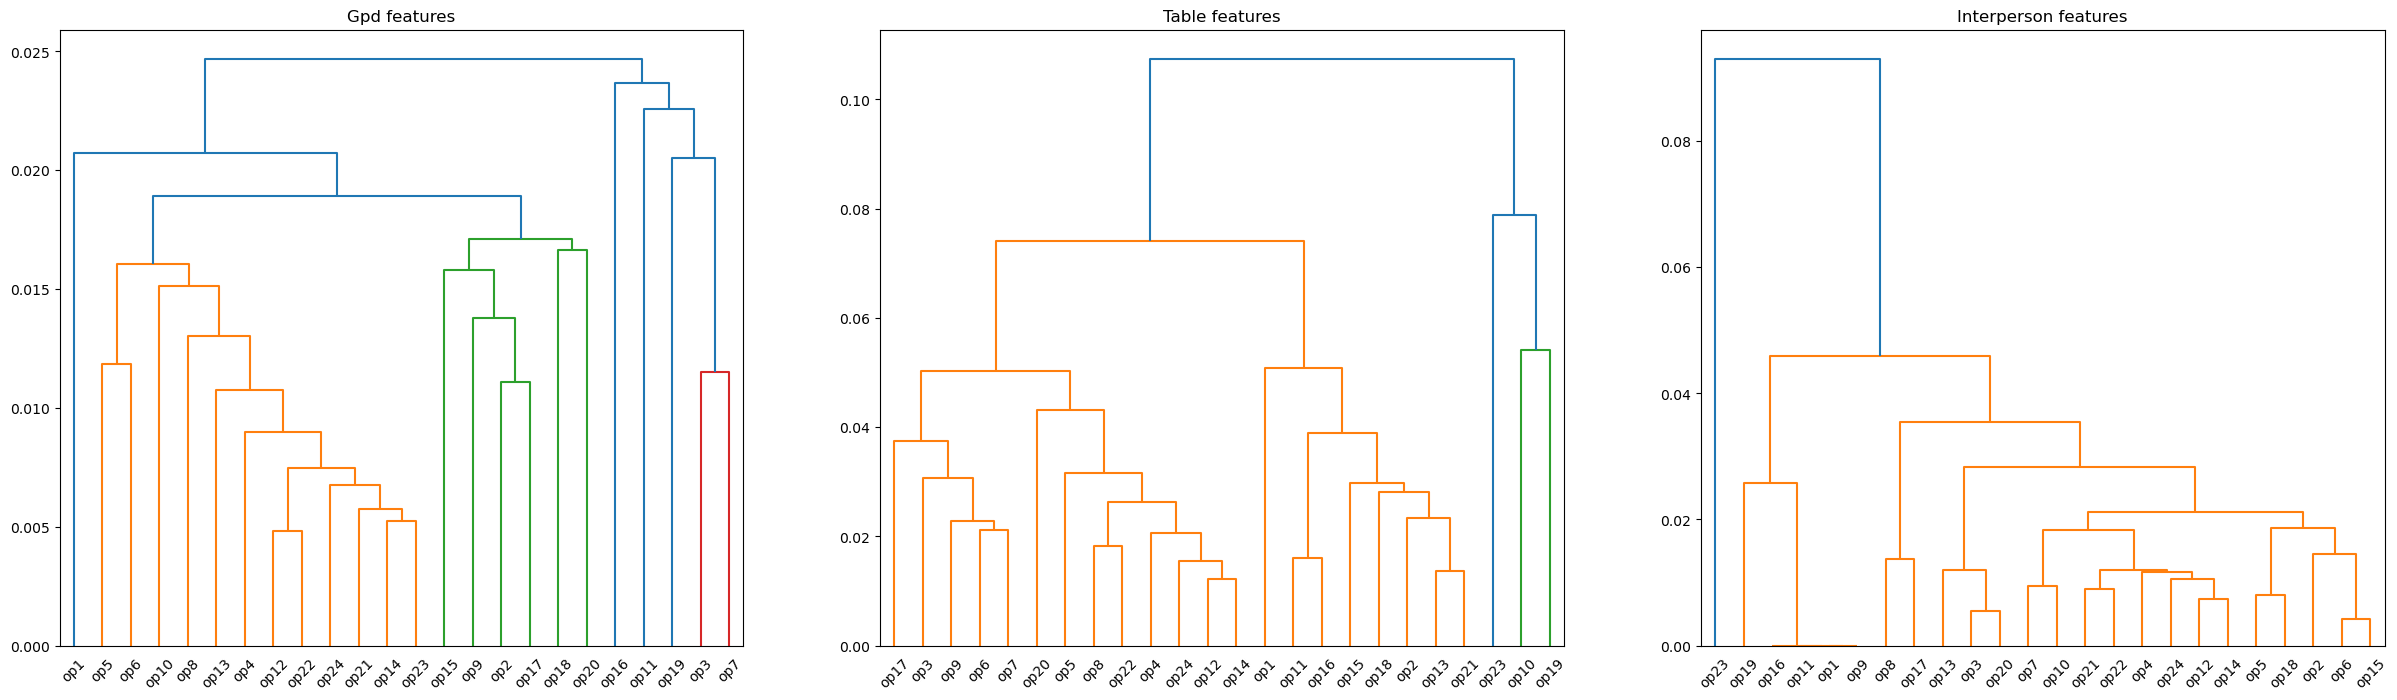

In [28]:
##plotting all 3 dendrograms side by side
fig, axes = plt.subplots(1, 3, figsize=(30, 8))
ax1, ax2, ax3 = axes.flatten()

dendrogram(g_linkage,  ax = ax1, labels = opLabels)
dendrogram(t_linkage, ax = ax2, labels = opLabels)
dendrogram(i_linkage, ax = ax3, labels = opLabels)

ax1.set_title("Gpd features")
ax2.set_title("Table features")
ax3.set_title("Interperson features")

plt.show()

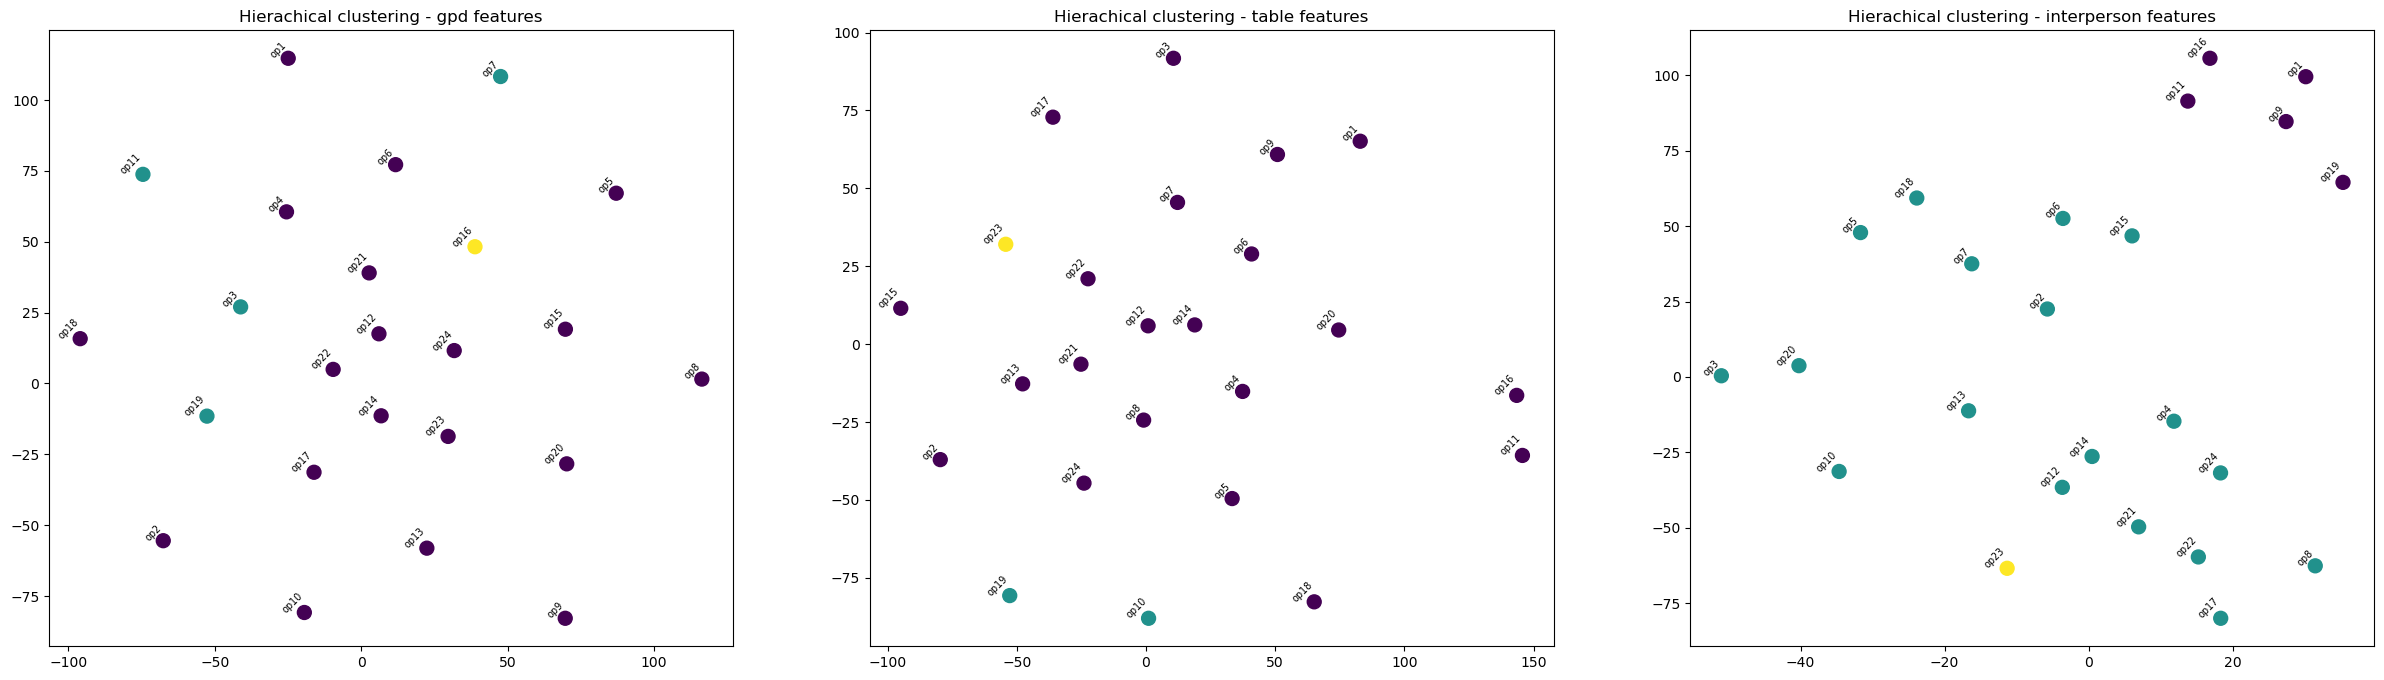

In [32]:
gpd_hierachical_labels = fcluster(g_linkage, t=3, criterion='maxclust') 
table_hierachical_labels = fcluster(t_linkage, t=3, criterion='maxclust') 
interp_hierachical_labels = fcluster(i_linkage, t=3, criterion='maxclust') 

fig, axes = plt.subplots(1, 3, figsize=(30, 8))
ax1, ax2, ax3 = axes.flatten()

ax1.scatter(gpdEmbedding[:, 0], gpdEmbedding[:,1], c=gpd_hierachical_labels, s=100)

for i, op in enumerate(opLabels):
    ax1.annotate(op, (gpdEmbedding[i, 0], gpdEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)


ax2.scatter(tableEmbedding[:, 0], tableEmbedding[:,1], c=table_hierachical_labels, s=100)

for i, op in enumerate(opLabels):
    ax2.annotate(op, (tableEmbedding[i, 0], tableEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)

ax3.scatter(interpersonEmbedding[:, 0], interpersonEmbedding[:,1], c=interp_hierachical_labels, s=100)

for i, op in enumerate(opLabels):
    ax3.annotate(op, (interpersonEmbedding[i, 0], interpersonEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)

ax1.set_title(f"Hierachical clustering - gpd features")
ax2.set_title(f"Hierachical clustering - table features")
ax3.set_title(f"Hierachical clustering - interperson features")


plt.show()

In [34]:
from sklearn.metrics.cluster import adjusted_rand_score, fowlkes_mallows_score

In [35]:
print(f'ARI gpd v table: {adjusted_rand_score(gpd_hierachical_labels, table_hierachical_labels)}')
print(f'ARI gpd v interperson: {adjusted_rand_score(gpd_hierachical_labels, interp_hierachical_labels)}')
print(f'ARI table vs interperson: {adjusted_rand_score(table_hierachical_labels, interp_hierachical_labels)}')

ARI gpd v table: 0.06278940544545286
ARI gpd v interperson: 0.28208533953179477
ARI table vs interperson: 0.27870375747720544


In [38]:
_, gpd_kmeans = kMeans_nDTW(gpdVectors , k=3)


In [39]:
_, table_kmeans = kMeans_nDTW(tableVectors , k=3)


In [40]:
_, interperson_kmeans = kMeans_nDTW(interpersonVectors , k=3)

Text(0.5, 1.0, 'Kmeans (k=3) - interperson features')

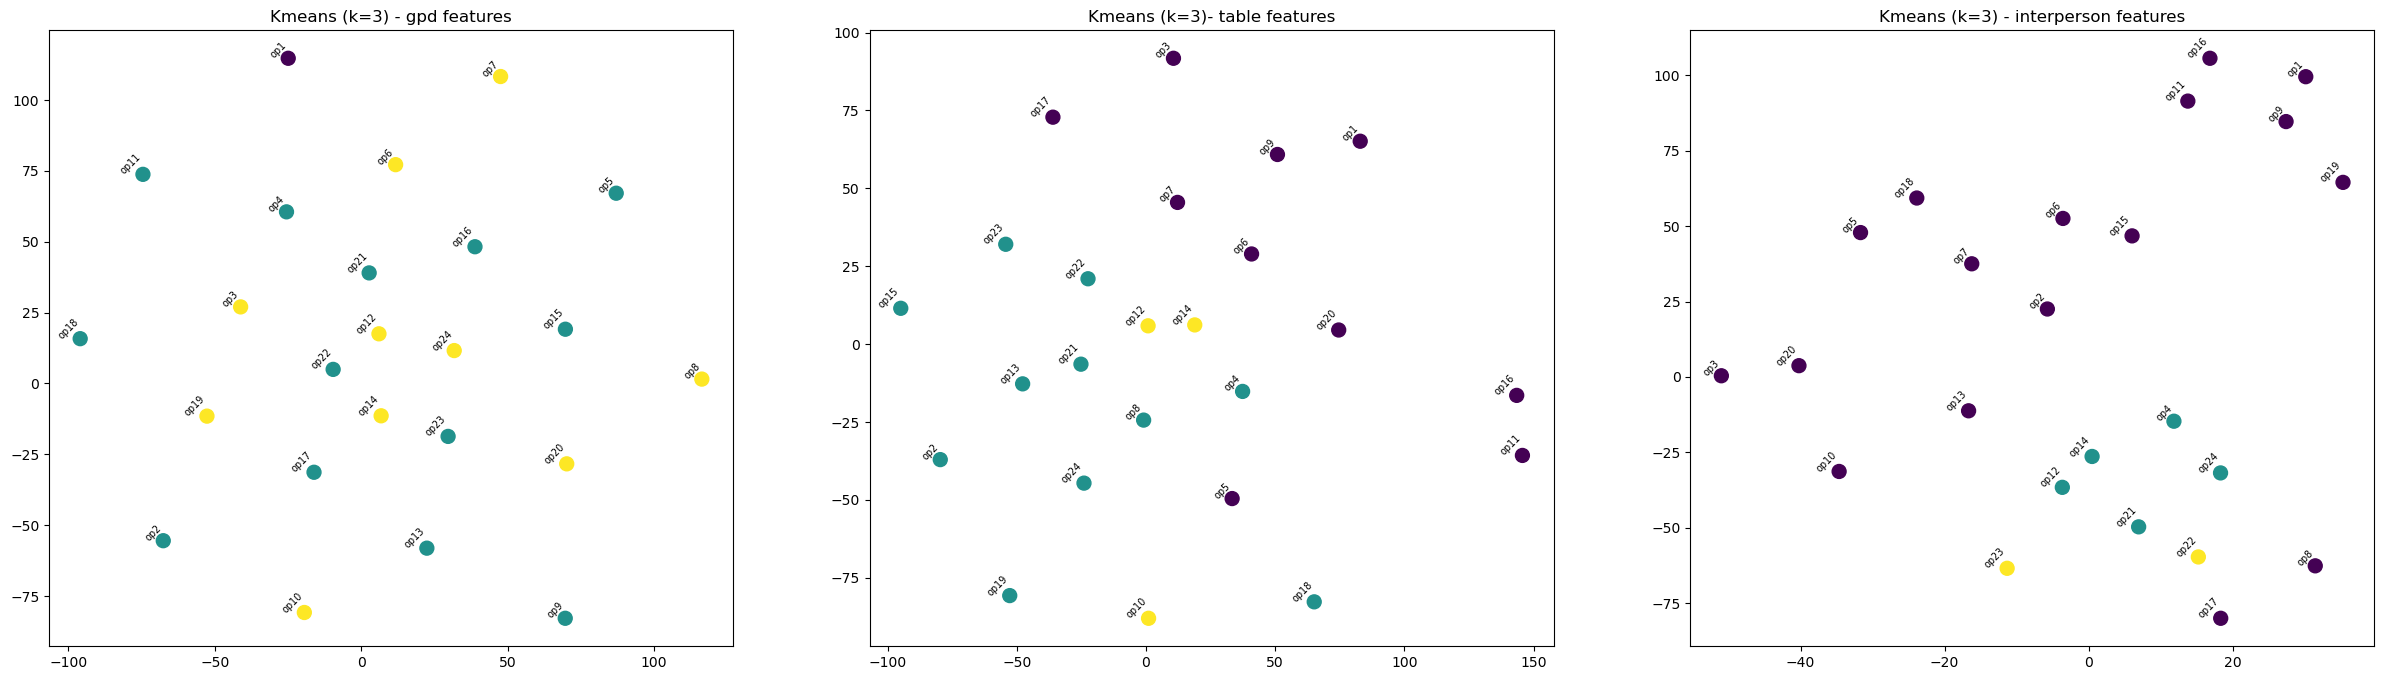

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(30, 8))
ax1, ax2, ax3 = axes.flatten()

ax1.scatter(gpdEmbedding[:, 0], gpdEmbedding[:,1], c=gpd_kmeans, s=100)

for i, op in enumerate(opLabels):
    ax1.annotate(op, (gpdEmbedding[i, 0], gpdEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)


ax2.scatter(tableEmbedding[:, 0], tableEmbedding[:,1], c=table_kmeans, s=100)

for i, op in enumerate(opLabels):
    ax2.annotate(op, (tableEmbedding[i, 0], tableEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)

ax3.scatter(interpersonEmbedding[:, 0], interpersonEmbedding[:,1], c=interperson_kmeans, s=100)

for i, op in enumerate(opLabels):
    ax3.annotate(op, (interpersonEmbedding[i, 0], interpersonEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)

ax1.set_title(f"Kmeans (k=3) - gpd features")
ax2.set_title(f"Kmeans (k=3)- table features")
ax3.set_title(f"Kmeans (k=3) - interperson features")

In [48]:
print(f'ARI gpd v table: {adjusted_rand_score(gpd_kmeans, table_kmeans)}')
print(f'ARI gpd v interperson: {adjusted_rand_score(gpd_kmeans, interperson_kmeans)}')
print(f'ARI table vs interperson: {adjusted_rand_score(table_kmeans, interperson_kmeans)}')

ARI gpd v table: 0.06107241211728495
ARI gpd v interperson: -0.050524010636633816
ARI table vs interperson: 0.14458391445839144


In [44]:
_, gpd_kmeans_k2 = kMeans_nDTW(gpdVectors)
_, table_kmeans_k2 = kMeans_nDTW(tableVectors)
_, interperson_kmeans_k2 = kMeans_nDTW(interpersonVectors)

Text(0.5, 1.0, 'Kmeans (k=2) - interperson features')

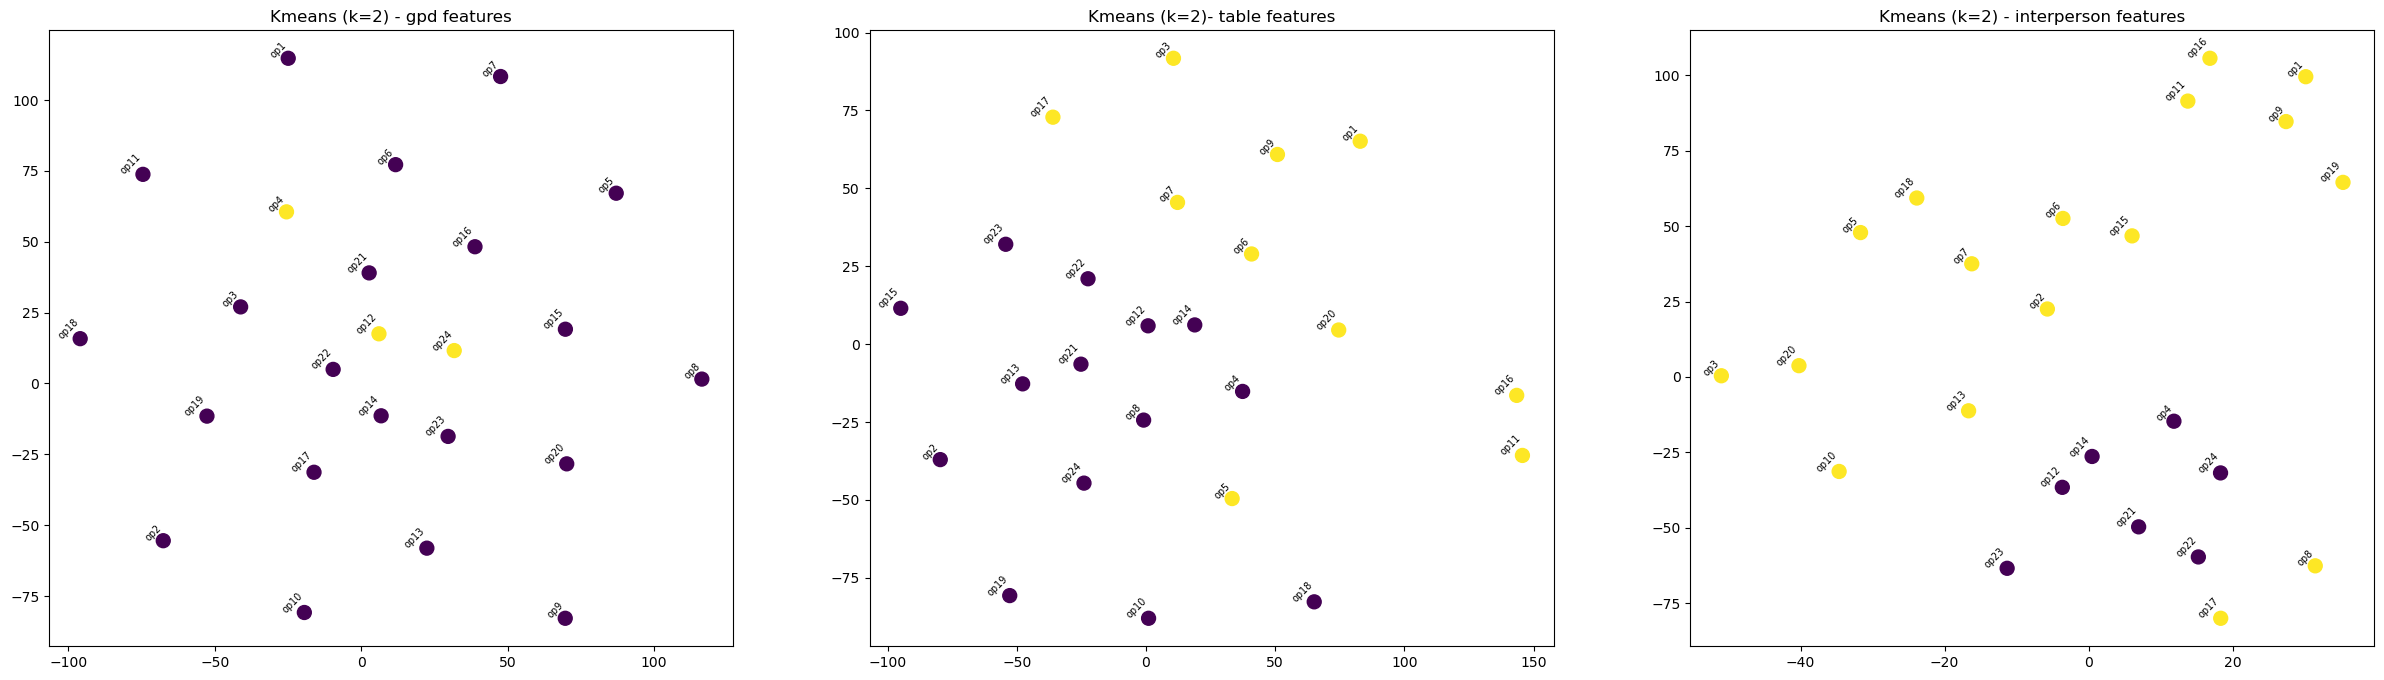

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(30, 8))
ax1, ax2, ax3 = axes.flatten()

ax1.scatter(gpdEmbedding[:, 0], gpdEmbedding[:,1], c=gpd_kmeans_k2, s=100)

for i, op in enumerate(opLabels):
    ax1.annotate(op, (gpdEmbedding[i, 0], gpdEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)


ax2.scatter(tableEmbedding[:, 0], tableEmbedding[:,1], c=table_kmeans_k2, s=100)

for i, op in enumerate(opLabels):
    ax2.annotate(op, (tableEmbedding[i, 0], tableEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)

ax3.scatter(interpersonEmbedding[:, 0], interpersonEmbedding[:,1], c=interperson_kmeans_k2, s=100)

for i, op in enumerate(opLabels):
    ax3.annotate(op, (interpersonEmbedding[i, 0], interpersonEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)

ax1.set_title(f"Kmeans (k=2) - gpd features")
ax2.set_title(f"Kmeans (k=2)- table features")
ax3.set_title(f"Kmeans (k=2) - interperson features")

In [49]:
print(f'ARI gpd v table: {adjusted_rand_score(gpd_kmeans_k2, table_kmeans_k2)}')
print(f'ARI gpd v interperson: {adjusted_rand_score(gpd_kmeans_k2, interperson_kmeans_k2)}')
print(f'ARI table vs interperson: {adjusted_rand_score(table_kmeans_k2, interperson_kmeans_k2)}')

ARI gpd v table: -0.028133791809940606
ARI gpd v interperson: 0.37340371190192406
ARI table vs interperson: 0.13939838591342626


### Algorithm agreement

In [50]:
print(f'ARI gpd : {adjusted_rand_score(gpd_kmeans, gpd_hierachical_labels)}')
print(f'ARI interperson: {adjusted_rand_score(interperson_kmeans, interp_hierachical_labels)}')
print(f'ARI table: {adjusted_rand_score(table_kmeans, table_hierachical_labels)}')

ARI gpd : 0.00168118600030567
ARI interperson: -0.011956001912960305
ARI table: 0.04162229732858003


### Comparing results against annotations

In [51]:
orientation_labels = [1, 1, 1, 2, 1, 2, 1, 3, 2, 1, 2, 2, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1] # 1 if down, 2 if up, 3 if side
machinery_labels = [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1] # 1 if c machine is present, 0 otherwise

labelsk2 = [gpd_kmeans_k2, table_kmeans_k2, interperson_kmeans_k2]
labelsk3 = [gpd_kmeans, gpd_hierachical_labels, interperson_kmeans, interp_hierachical_labels, table_kmeans, table_hierachical_labels]

In [53]:
for i, label in enumerate(labelsk3):    
    print(f'ARI: {adjusted_rand_score(orientation_labels, labelsk3[i])}')


ARI: -0.04101838755304102
ARI: -0.006181645268663814
ARI: -0.0739864331913551
ARI: 0.06879645737782698
ARI: -0.052169826100579665
ARI: -0.026294820717131476


In [55]:
for i, label in enumerate(labelsk2): 
    print(f'ARI: {adjusted_rand_score(machinery_labels, labelsk2[i])}')


ARI: 0.30210506353119665
ARI: 0.026136957658128592
ARI: 0.3943051516980304


Text(0.5, 1.0, 'machinery - interperson embedding')

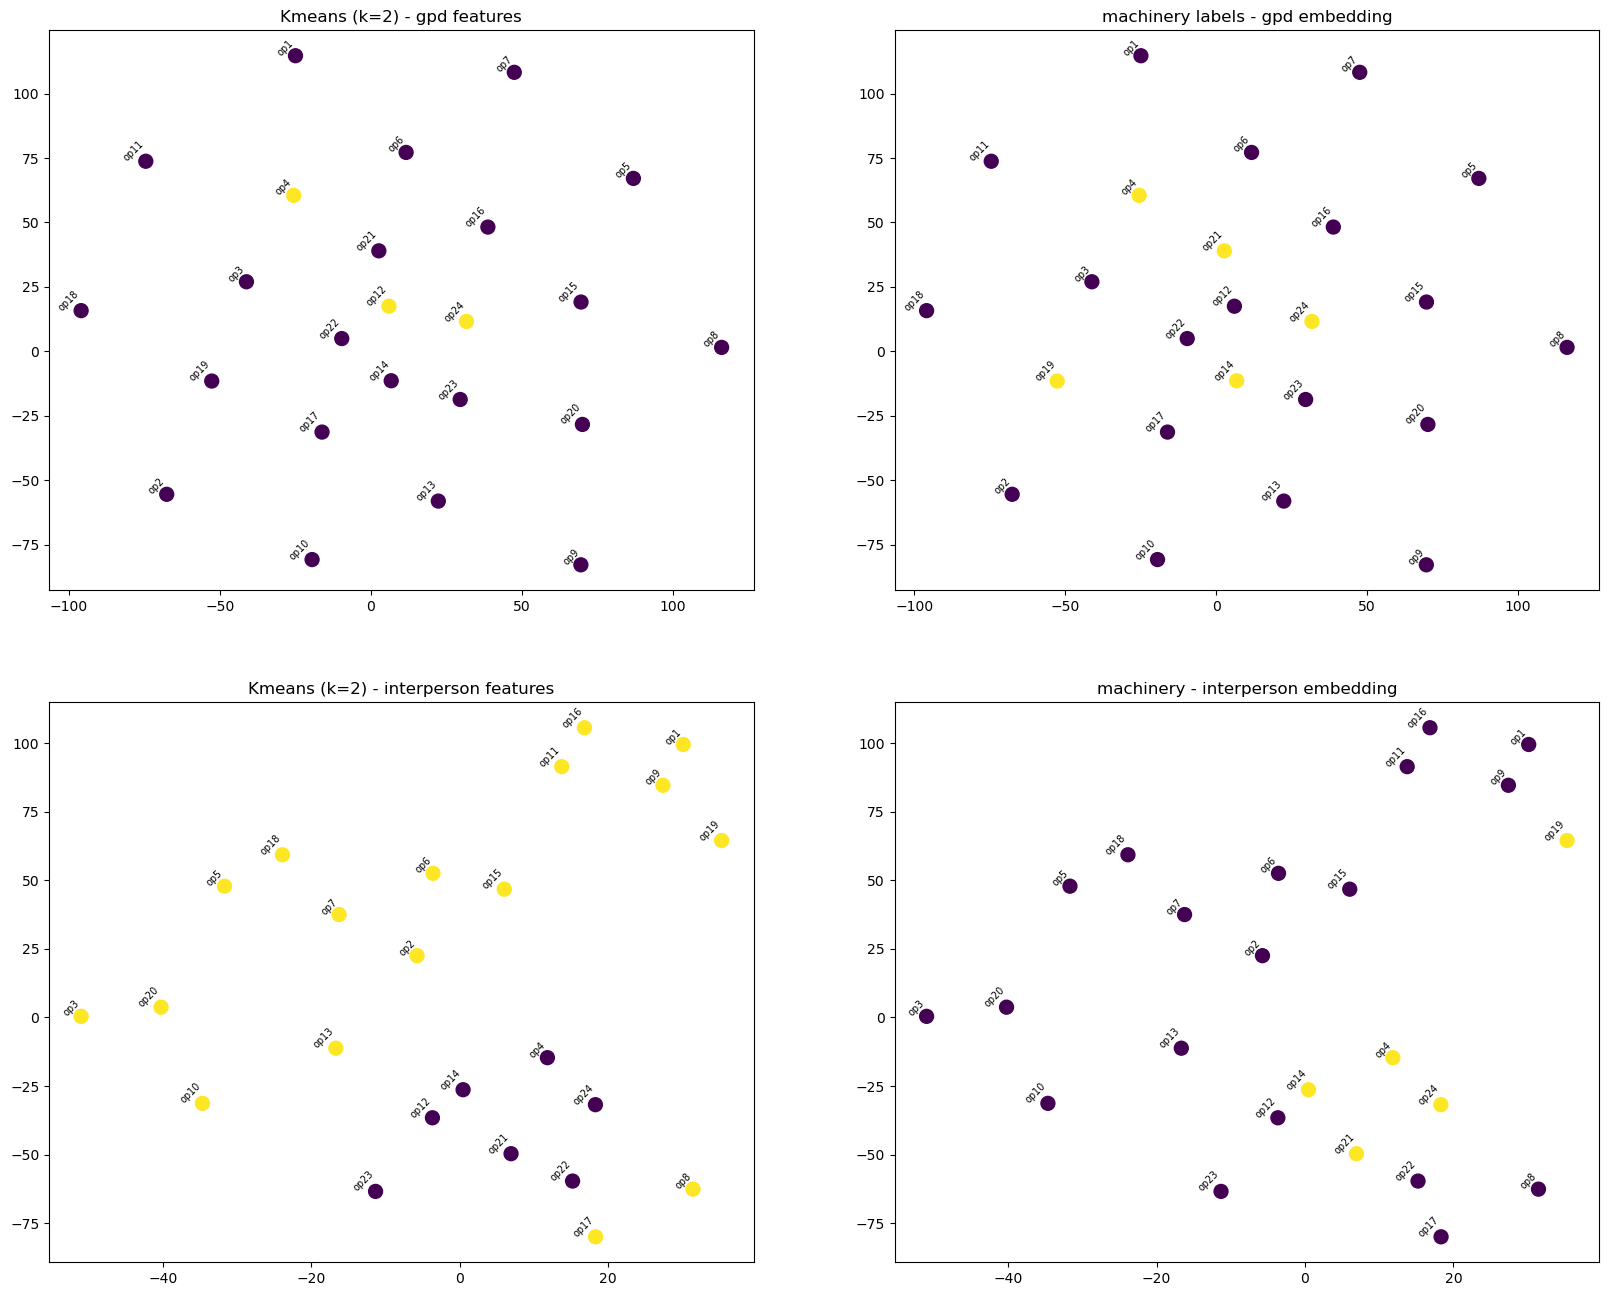

In [71]:
fig, axes = plt.subplots(2, 2, figsize=(20,16))
ax1, ax2, ax3, ax4 = axes.flatten()

ax1.scatter(gpdEmbedding[:, 0], gpdEmbedding[:,1], c=gpd_kmeans_k2, s=100)

for i, op in enumerate(opLabels):
    ax1.annotate(op, (gpdEmbedding[i, 0], gpdEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)


ax2.scatter(gpdEmbedding[:, 0], gpdEmbedding[:,1], c=machinery_labels, s=100)

for i, op in enumerate(opLabels):
    ax2.annotate(op, (gpdEmbedding[i, 0], gpdEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)


ax3.scatter(interpersonEmbedding[:, 0], interpersonEmbedding[:,1], c=interperson_kmeans_k2, s=100)

for i, op in enumerate(opLabels):
    ax3.annotate(op, (interpersonEmbedding[i, 0], interpersonEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)

ax4.scatter(interpersonEmbedding[:, 0], interpersonEmbedding[:,1], c=machinery_labels, s=100)

for i, op in enumerate(opLabels):
    ax4.annotate(op, (interpersonEmbedding[i, 0], interpersonEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)

ax1.set_title(f"Kmeans (k=2) - gpd features")
ax2.set_title(f"machinery labels - gpd embedding")


ax3.set_title(f"Kmeans (k=2) - interperson features")
ax4.set_title(f"machinery - interperson embedding")


#### operations over 10 frames

In [58]:
gpd_over10 = []
table_over10 = []
interperson_over10 = []

for i, operation in enumerate(gpdVectors):
    if len(operation)>=10:
        gpd_over10.append(gpdVectors[i])
        table_over10.append(tableVectors[i])
        interperson_over10.append(interpersonVectors[i])

In [59]:
_, gpd_over10_kmeans = kMeans_nDTW(gpd_over10)
_, table_over10_kmeans= kMeans_nDTW(table_over10)
_, interperson_over10_kmeans = kMeans_nDTW(interperson_over10)

In [ ]:
labels_over10 = [gpd_over10_kmeans, table_over10_kmeans, interperson_over10_kmeans]

machinery_labels_over10 =   [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1] # 1 if c machine is present, 0 otherwise


In [62]:
for i, label in enumerate(labels_over10): 
    print(f'ARI: {adjusted_rand_score(machinery_labels_over10, labels_over10[i])}')

ARI: 0.02264808362369338
ARI: -0.08896797153024912
ARI: 0.5557491289198606


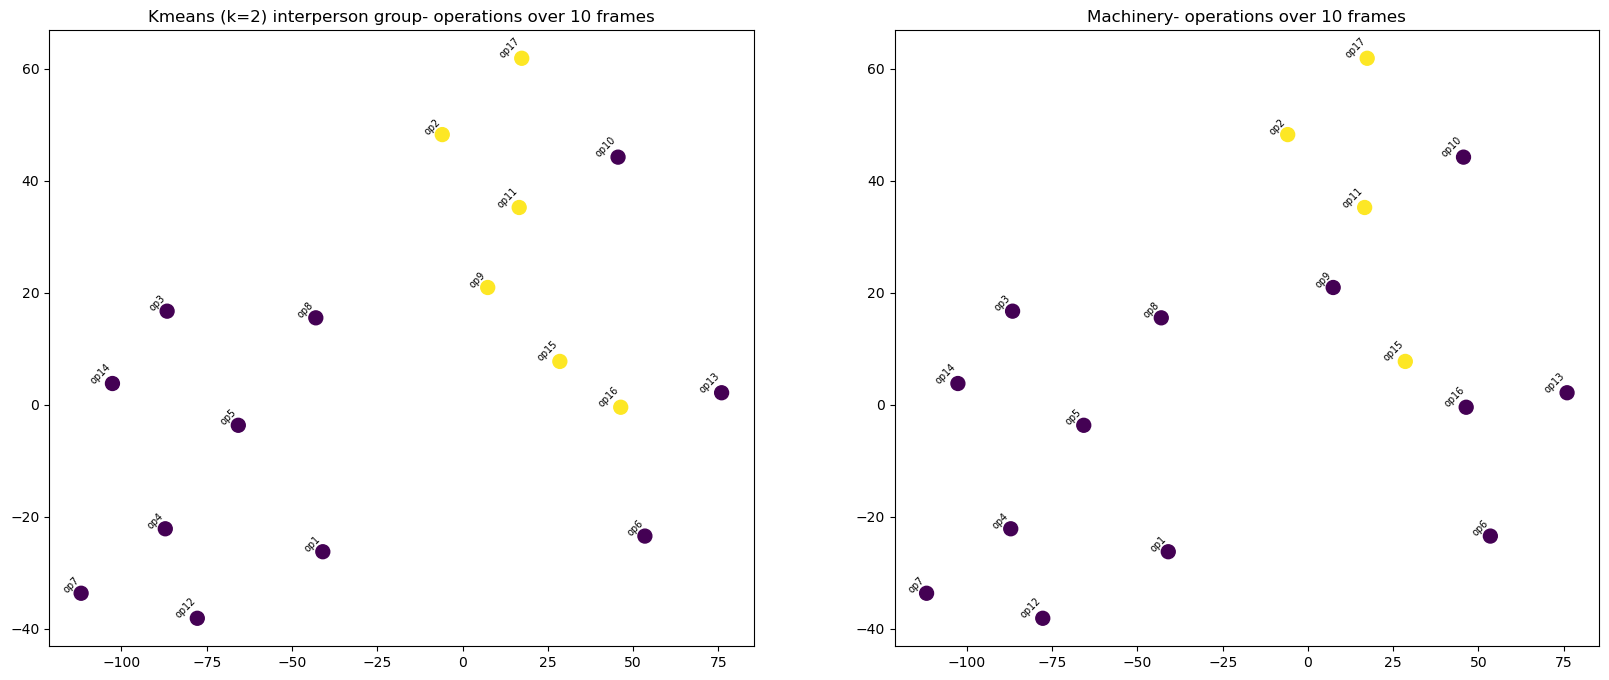

In [66]:
interpersonDists_over10 = n_dtw(interperson_over10)
interpersonEmbedding_over10 = TSNE(n_components=2, metric='precomputed', 
                 random_state=42, init='random', 
                 perplexity=5).fit_transform(interpersonDists_over10)

over10Labels = [f'op{i}' for i in range(1,len(interperson_over10)+1)]


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

ax1.scatter(interpersonEmbedding_over10[:, 0], interpersonEmbedding_over10[:,1], c=interperson_over10_kmeans, s=100)

for i, op in enumerate(over10Labels):
    ax1.annotate(op, (interpersonEmbedding_over10[i, 0], interpersonEmbedding_over10[i ,1]), fontsize=7, ha='right', rotation=45)


ax2.scatter(interpersonEmbedding_over10[:, 0], interpersonEmbedding_over10[:,1], c=machinery_labels_over10, s=100)

for i, op in enumerate(over10Labels):
    ax2.annotate(op, (interpersonEmbedding_over10[i, 0], interpersonEmbedding_over10[i ,1]), fontsize=7, ha='right', rotation=45)

    
ax1.set_title(f"Kmeans (k=2) interperson group- operations over 10 frames")
ax2.set_title(f"Machinery- operations over 10 frames")

plt.show()

## Feature group subsets

In [87]:
gpd_table_matrix = np.hstack([gpdMatrix, tableMatrix])
gpd_interperson_matrix = np.hstack([gpdMatrix, interpersonMatrix])
table_interperson_matrix = np.hstack([interpersonMatrix, tableMatrix])

In [88]:
gpdTable = []
gpdInterperson = []
tableInterperson = []

for r in OP_RANGES:
    op = gpd_table_matrix[r[0]:r[1]+1,]
    gpdTable.append(op)

for r in OP_RANGES:
    op = gpd_interperson_matrix[r[0]:r[1]+1,]
    gpdInterperson.append(op)


for r in OP_RANGES:
    op = table_interperson_matrix[r[0]:r[1]+1,]
    tableInterperson.append(op)

In [ ]:
gpdTableDists = n_dtw(gpdTable)
gpdTableEmbedding = TSNE(n_components=2, metric='precomputed', 
                 random_state=42, init='random', 
                 perplexity=5).fit_transform(gpdTableDists)

gpdInterpersonDists = n_dtw(gpdInterperson)
gpdInterpersonEmbedding = TSNE(n_components=2, metric='precomputed', 
                 random_state=42, init='random', 
                 perplexity=5).fit_transform(gpdInterpersonDists)

tableInterpersonDists = n_dtw(tableInterperson)
interpersonEmbedding = TSNE(n_components=2, metric='precomputed', 
                 random_state=42, init='random', 
                 perplexity=5).fit_transform(tableInterpersonDists)


gt_condensedDist = squareform(gpdTableDists)
gt_linkage = linkage(gt_condensedDist, method='complete') 

gi_condensedDist = squareform(gpdInterpersonDists)
gi_linkage = linkage(gi_condensedDist, method='complete') 

ti_condensedDist = squareform(tableInterpersonDists)
ti_linkage = linkage(ti_condensedDist, method='complete') 

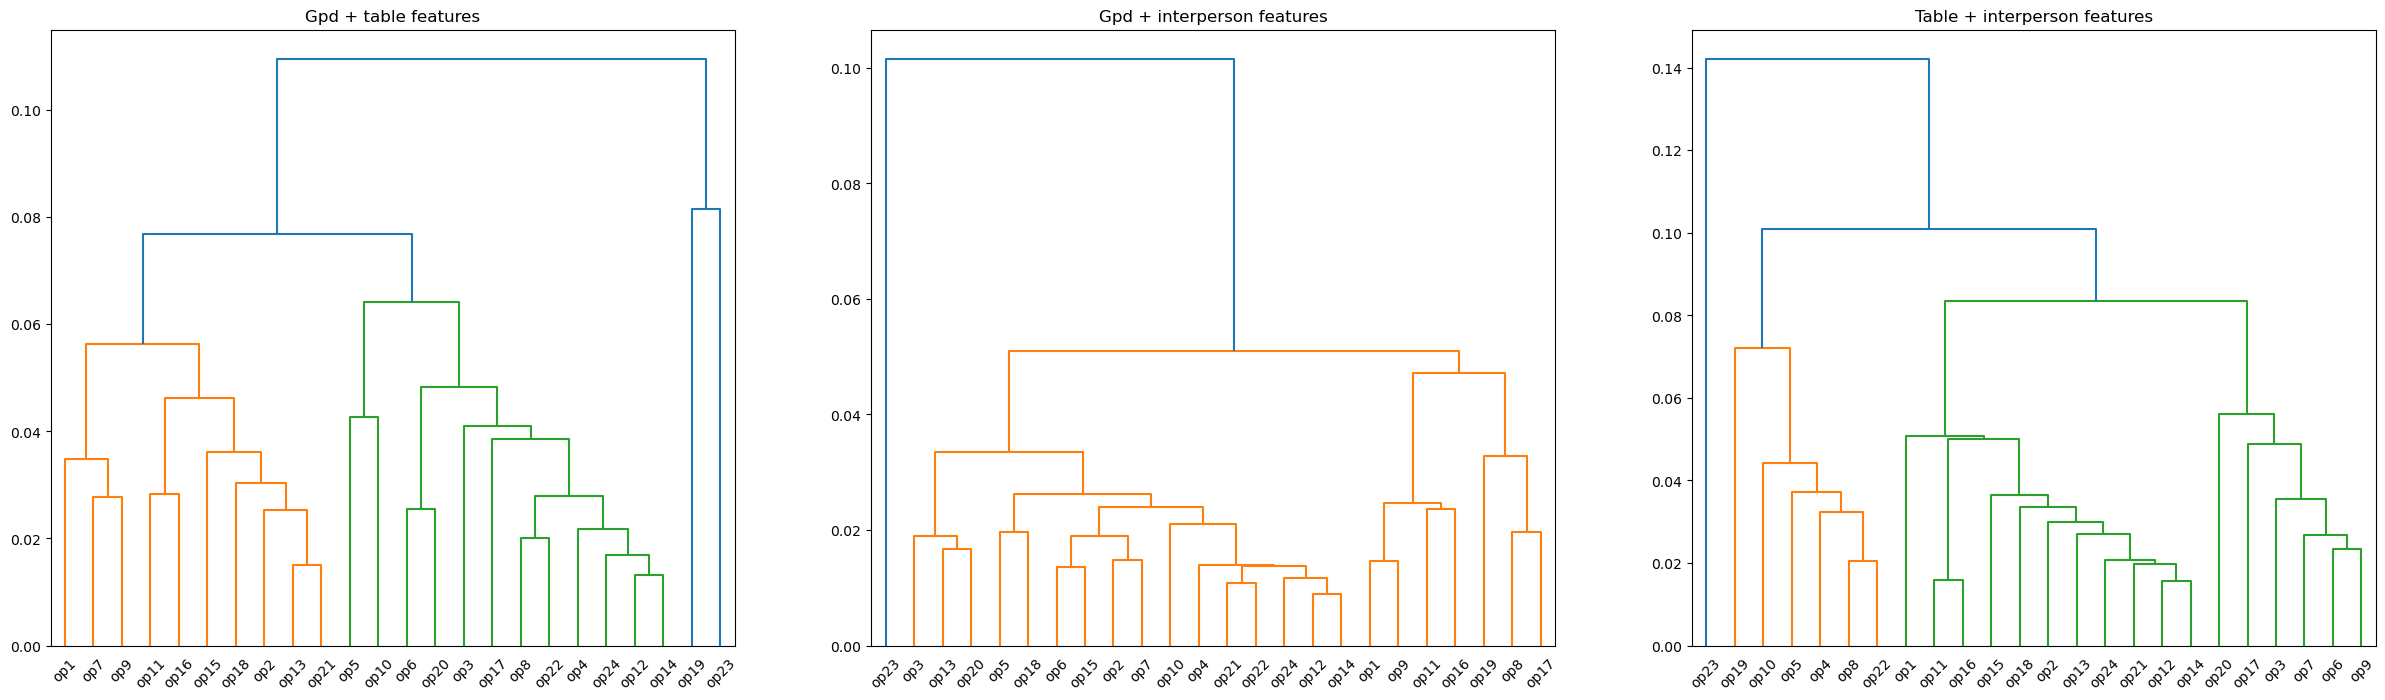

In [90]:
fig, axes = plt.subplots(1, 3, figsize=(30, 8))
ax1, ax2, ax3 = axes.flatten()

dendrogram(gt_linkage,  ax = ax1, labels = opLabels)
dendrogram(gi_linkage, ax = ax2, labels = opLabels)
dendrogram(ti_linkage, ax = ax3, labels = opLabels)

ax1.set_title("Gpd + table features")
ax2.set_title("Gpd + interperson features")
ax3.set_title("Table + interperson features")

plt.show()

Text(0.5, 1.0, 'HC (k=3) - table + interperson features')

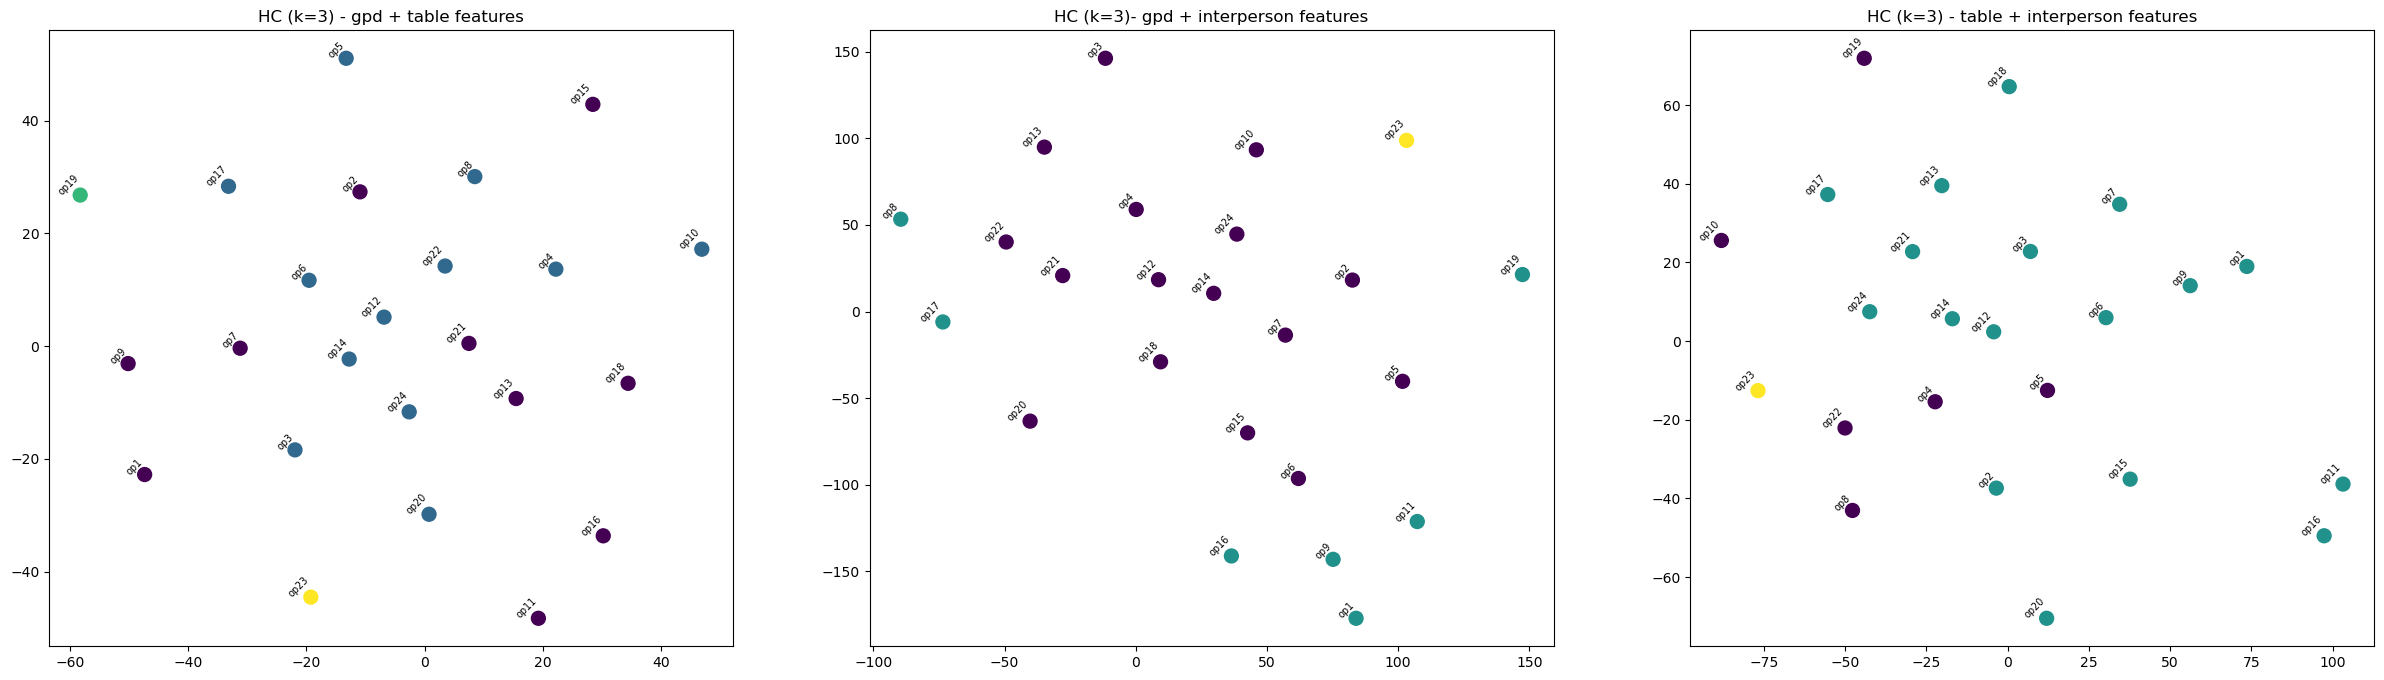

In [ ]:
##grouping subsets (k=3)
gt_hierachical_labels = fcluster(gt_linkage, t=4, criterion='maxclust')  #19 and 23 were being given their own clusters at k=3
gi_hierachical_labels = fcluster(gi_linkage, t=3, criterion='maxclust') 
ti_hierachical_labels = fcluster(ti_linkage, t=3, criterion='maxclust') 


fig, axes = plt.subplots(1, 3, figsize=(30, 8))
ax1, ax2, ax3 = axes.flatten()

ax1.scatter(gpdTableEmbedding[:, 0], gpdTableEmbedding[:,1], c=gt_hierachical_labels, s=100)

for i, op in enumerate(opLabels):
    ax1.annotate(op, (gpdTableEmbedding[i, 0], gpdTableEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)


ax2.scatter(gpdInterpersonEmbedding[:, 0], gpdInterpersonEmbedding[:,1], c=gi_hierachical_labels, s=100)

for i, op in enumerate(opLabels):
    ax2.annotate(op, (gpdInterpersonEmbedding[i, 0], gpdInterpersonEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)

ax3.scatter(interpersonEmbedding[:, 0], interpersonEmbedding[:,1], c=ti_hierachical_labels, s=100)

for i, op in enumerate(opLabels):
    ax3.annotate(op, (interpersonEmbedding[i, 0], interpersonEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)

ax1.set_title(f"HC (k=4) - gpd + table features")
ax2.set_title(f"HC (k=3)- gpd + interperson features")
ax3.set_title(f"HC (k=3) - table + interperson features")

In [98]:
##aggreement 
print(f"{adjusted_rand_score(gt_hierachical_labels, gi_hierachical_labels)}")
print(f"{adjusted_rand_score(ti_hierachical_labels, gt_hierachical_labels)}")
print(f"{adjusted_rand_score(ti_hierachical_labels, gi_hierachical_labels)}")

0.14854901960784314
0.21732405259087392
0.08508287292817679


In [ ]:
#kmeans k = 3
_, gpdTable_kmeans = kMeans_nDTW(gpdTable, k=3)
_, gpdInterperson_kmeans= kMeans_nDTW(gpdInterperson, k=3)
_, tableInterperson_kmeans = kMeans_nDTW(tableInterperson, k=3)

Text(0.5, 1.0, 'Kmeanse (k=3) - table + interperson features')

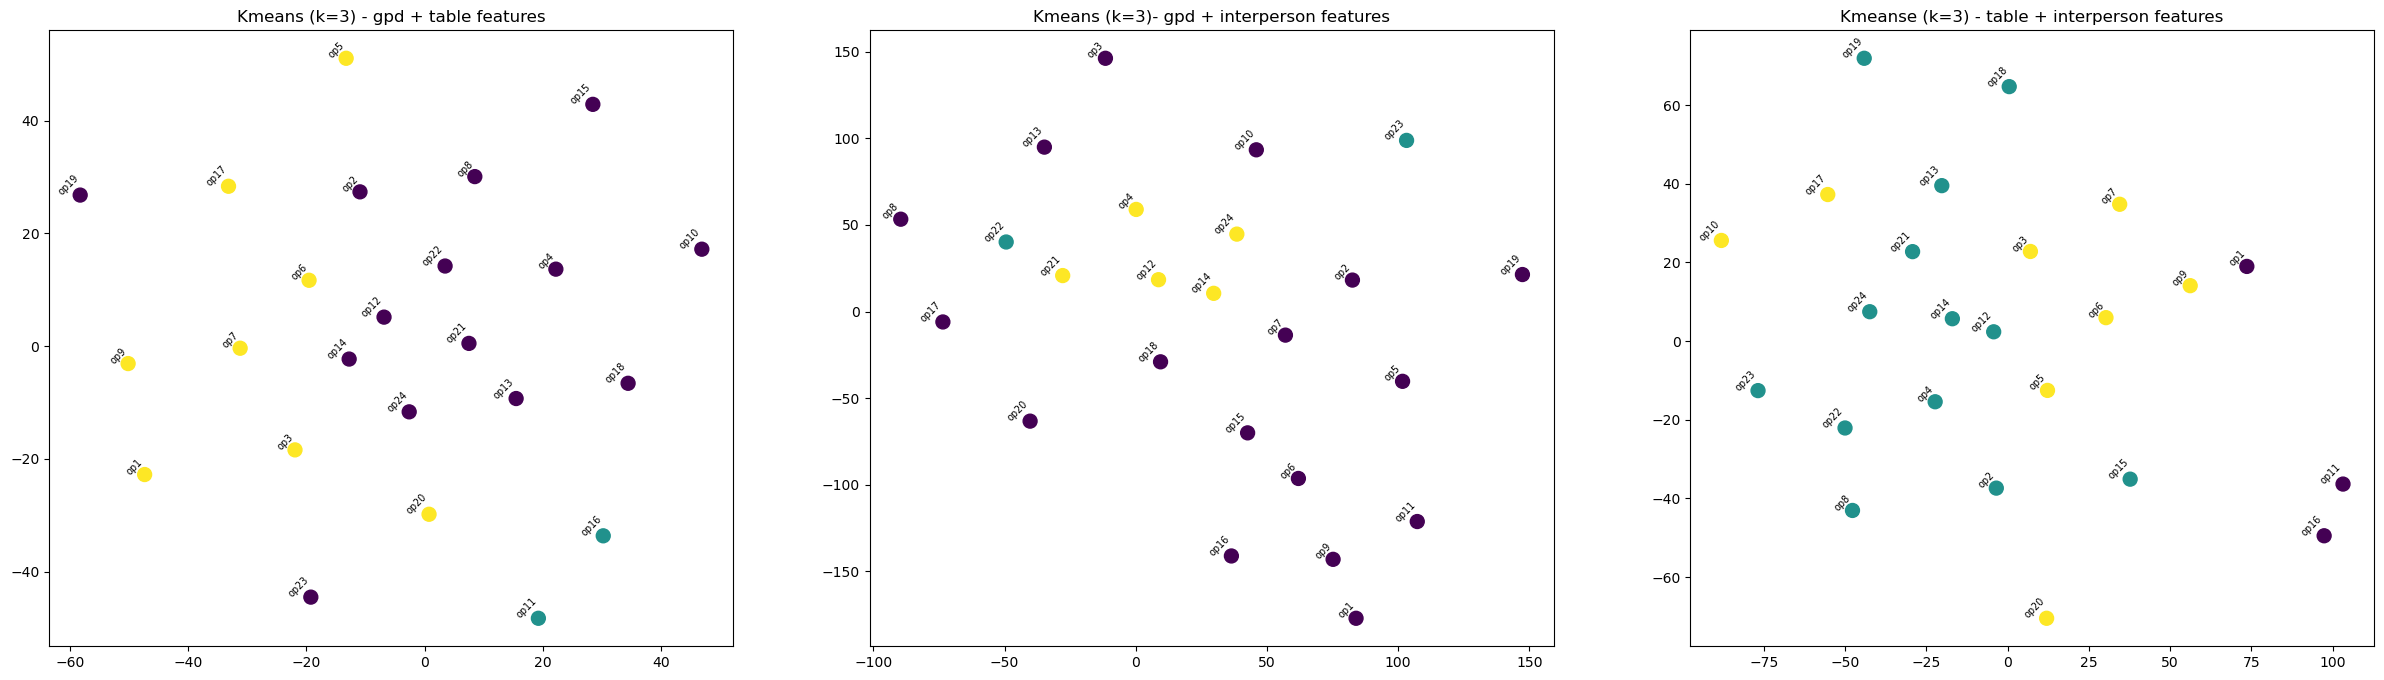

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(30, 8))
ax1, ax2, ax3 = axes.flatten()

ax1.scatter(gpdTableEmbedding[:, 0], gpdTableEmbedding[:,1], c=gpdTable_kmeans, s=100)

for i, op in enumerate(opLabels):
    ax1.annotate(op, (gpdTableEmbedding[i, 0], gpdTableEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)


ax2.scatter(gpdInterpersonEmbedding[:, 0], gpdInterpersonEmbedding[:,1], c=gpdInterperson_kmeans, s=100)

for i, op in enumerate(opLabels):
    ax2.annotate(op, (gpdInterpersonEmbedding[i, 0], gpdInterpersonEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)

ax3.scatter(interpersonEmbedding[:, 0], interpersonEmbedding[:,1], c=tableInterperson_kmeans , s=100)

for i, op in enumerate(opLabels):
    ax3.annotate(op, (interpersonEmbedding[i, 0], interpersonEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)

ax1.set_title(f"Kmeans (k=3) - gpd + table features")
ax2.set_title(f"Kmeans (k=3)- gpd + interperson features")
ax3.set_title(f"Kmeanse (k=3) - table + interperson features")

Text(0.5, 1.0, 'Kmeanse (k=2) - table + interperson features')

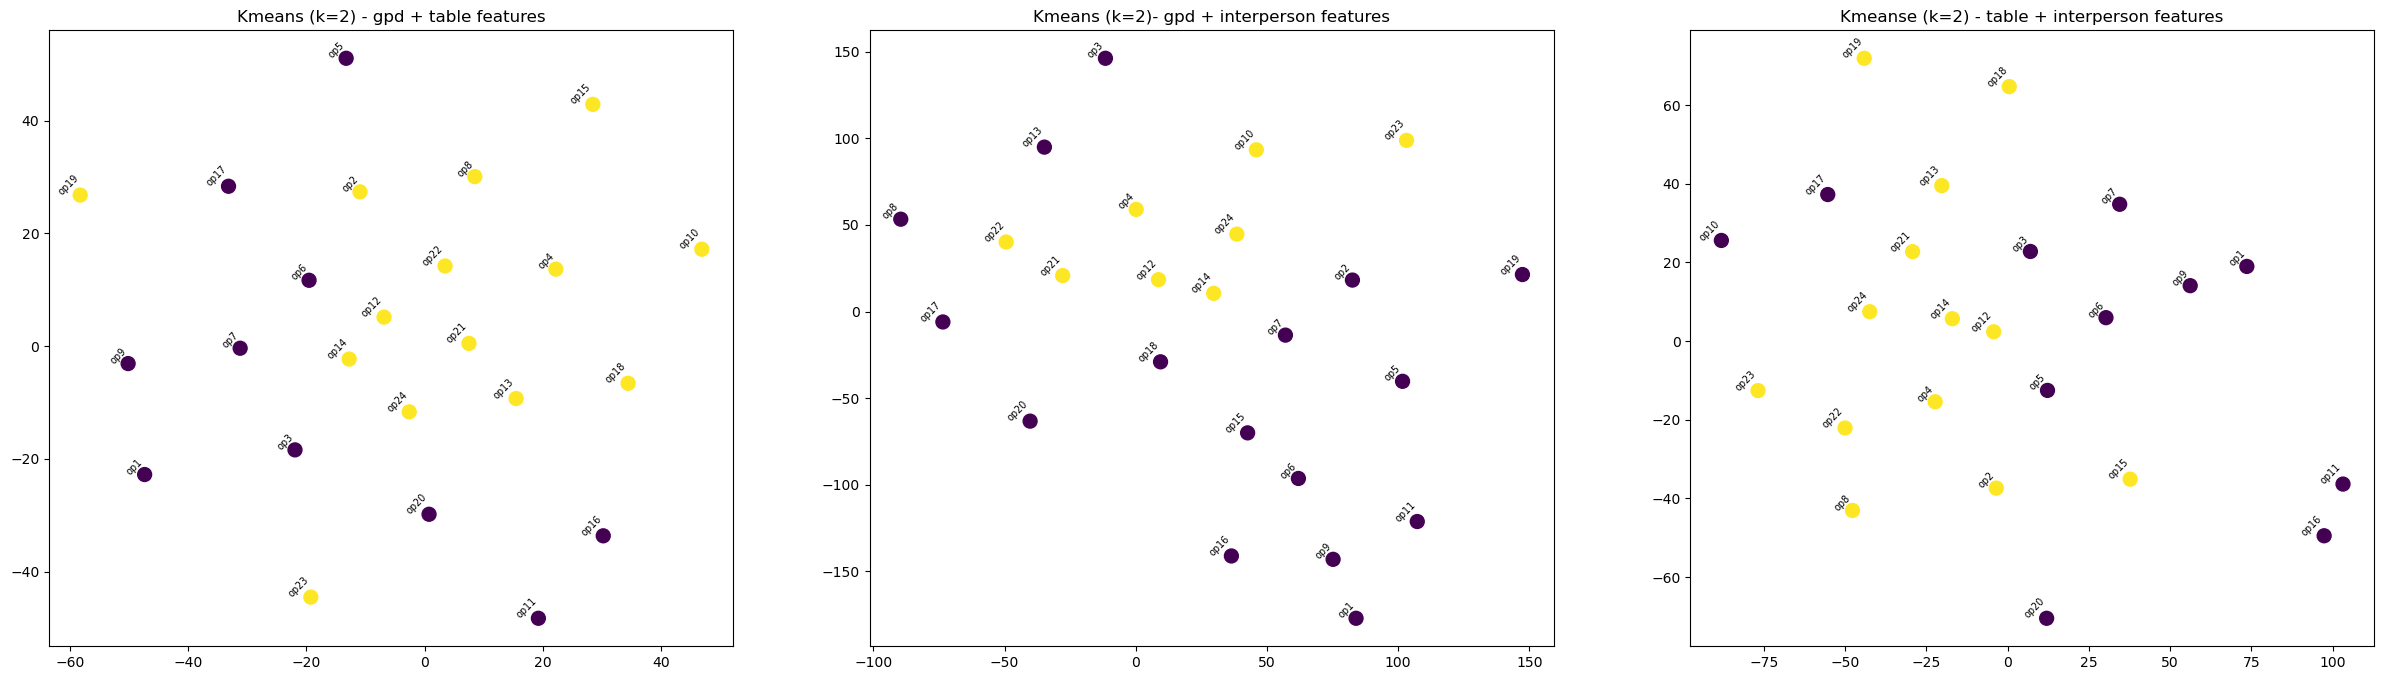

In [ ]:
# kmeans k = 2
_, gpdTable_kmeans_k2 = kMeans_nDTW(gpdTable)
_, gpdInterperson_kmeans_k2= kMeans_nDTW(gpdInterperson)
_, tableInterperson_kmeans_k2 = kMeans_nDTW(tableInterperson)

fig, axes = plt.subplots(1, 3, figsize=(30, 8))
ax1, ax2, ax3 = axes.flatten()

ax1.scatter(gpdTableEmbedding[:, 0], gpdTableEmbedding[:,1], c=gpdTable_kmeans_k2, s=100)

for i, op in enumerate(opLabels):
    ax1.annotate(op, (gpdTableEmbedding[i, 0], gpdTableEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)


ax2.scatter(gpdInterpersonEmbedding[:, 0], gpdInterpersonEmbedding[:,1], c=gpdInterperson_kmeans_k2, s=100)

for i, op in enumerate(opLabels):
    ax2.annotate(op, (gpdInterpersonEmbedding[i, 0], gpdInterpersonEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)

ax3.scatter(interpersonEmbedding[:, 0], interpersonEmbedding[:,1], c=tableInterperson_kmeans_k2 , s=100)

for i, op in enumerate(opLabels):
    ax3.annotate(op, (interpersonEmbedding[i, 0], interpersonEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)

ax1.set_title(f"Kmeans (k=2) - gpd + table features")
ax2.set_title(f"Kmeans (k=2)- gpd + interperson features")
ax3.set_title(f"Kmeans (k=2) - table + interperson features")



In [103]:
#comparing to manual annotations
subset_labels= [gpdTable_kmeans_k2, gpdInterperson_kmeans_k2, tableInterperson_kmeans_k2]

for i, label in enumerate(subset_labels): 
    print(f'ARI: {adjusted_rand_score(machinery_labels, subset_labels[i])}')

ARI: 0.026136957658128592
ARI: 0.2956914150639304
ARI: 0.08281842255568825


## Feature group weight ablation

In [73]:
try:
    with open('frameMatrixScaled.pkl', 'rb') as f:
        unweightedFrameMatrix = pickle.load(f)
except:
    print("Error")

In [75]:
unweighted_operations = []

for r in OP_RANGES:
    op = unweightedFrameMatrix[r[0]:r[1]+1,]
    unweighted_operations.append(op)

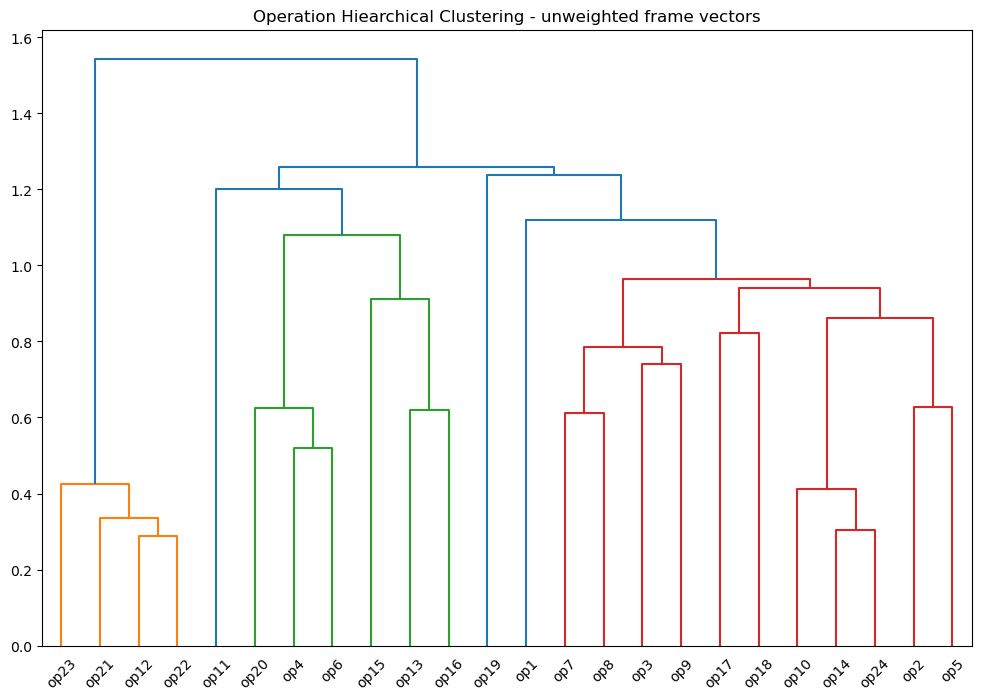

In [76]:
unweightedDists = n_dtw(unweighted_operations)
unweightedEmbedding = TSNE(n_components=2, metric='precomputed', 
                 random_state=42, init='random', 
                 perplexity=5).fit_transform(unweightedDists)

u_condensedDist = squareform(unweightedDists)
unweighted_linkage = linkage(u_condensedDist, method='complete') 


plt.figure(figsize=(12, 8))
dendrogram(unweighted_linkage, labels = opLabels)
plt.title("Operation Hiearchical Clustering - unweighted frame vectors")
plt.show()

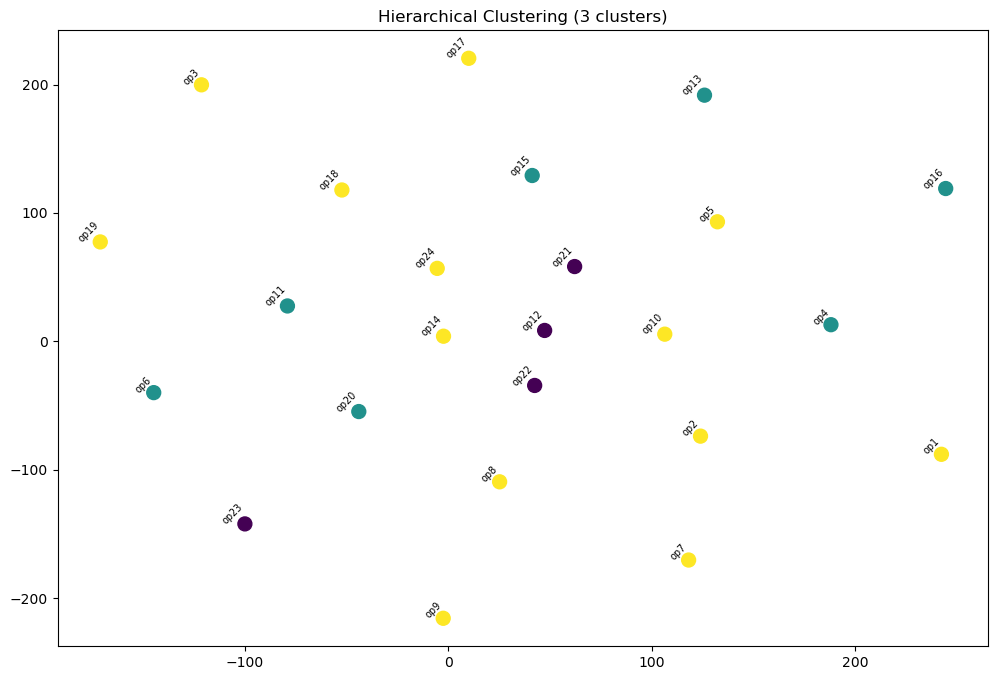

In [77]:
unweighted_hierachical_labels = fcluster(unweighted_linkage, t=3, criterion='maxclust') 

plt.figure(figsize=(12, 8))
plt.scatter(unweightedEmbedding[:, 0], unweightedEmbedding[:, 1], 
            c=unweighted_hierachical_labels, s=100)
for i, op in enumerate(opLabels):
    plt.annotate(op, (unweightedEmbedding[i, 0], unweightedEmbedding[i, 1]), fontsize=7, ha='right', rotation=45)
plt.title('Hierarchical Clustering (3 clusters)')
plt.show()

In [78]:
_, unweighted_kmeans = kMeans_nDTW(unweighted_operations, k=3)
_, unweighted_kmeans_k2 = kMeans_nDTW(unweighted_operations)

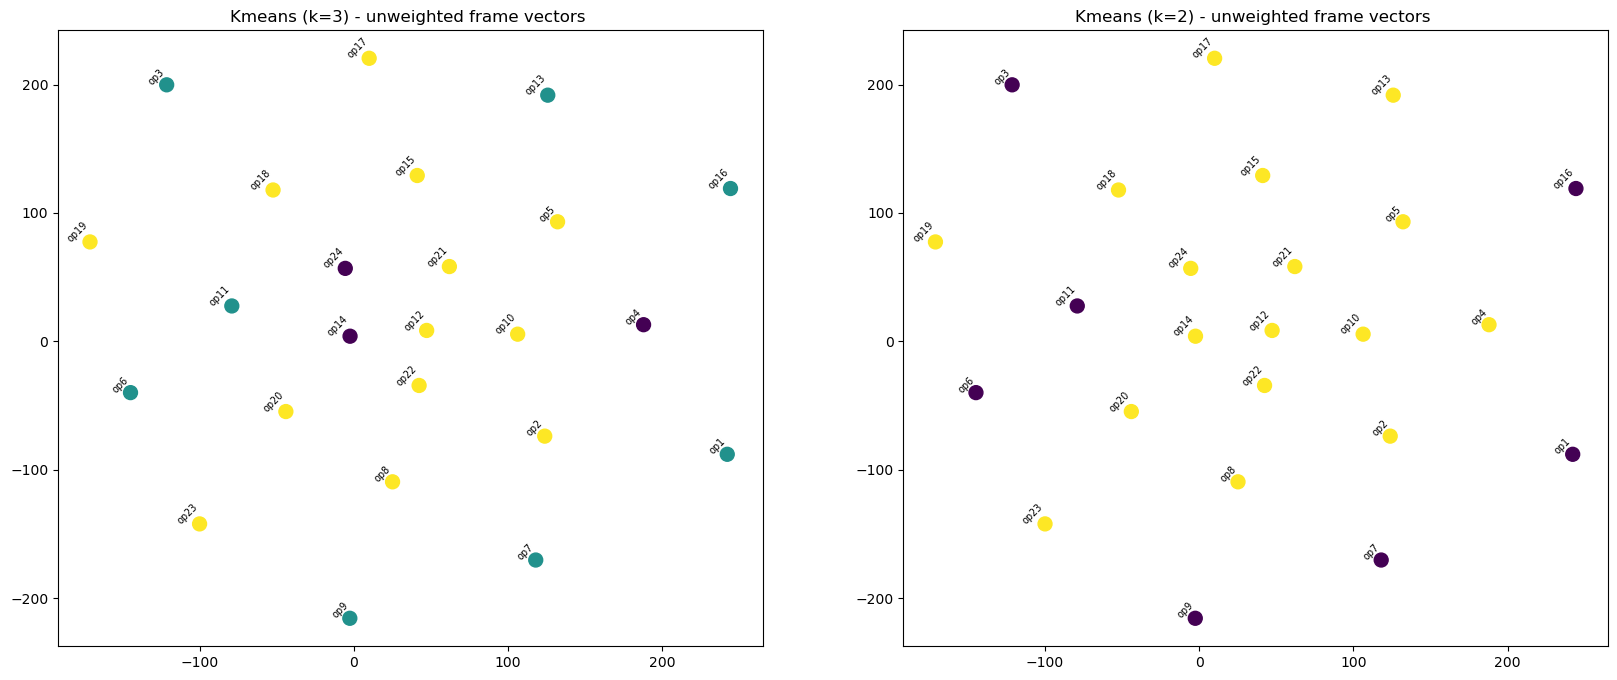

In [79]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

ax1.scatter(unweightedEmbedding[:, 0], unweightedEmbedding[:,1], c=unweighted_kmeans, s=100)

for i, op in enumerate(opLabels):
    ax1.annotate(op, (unweightedEmbedding[i, 0], unweightedEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)


ax2.scatter(unweightedEmbedding[:, 0], unweightedEmbedding[:,1], c=unweighted_kmeans_k2, s=100)

for i, op in enumerate(opLabels):
    ax2.annotate(op, (unweightedEmbedding[i, 0], unweightedEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)

    
ax1.set_title(f"Kmeans (k=3) - unweighted frame vectors ")
ax2.set_title(f"Kmeans (k=2) - unweighted frame vectors ")

plt.show()

In [ ]:
##comparison...